In [1]:
# %pip install "numpy<2" --upgrade --force-reinstall

In [2]:
import numpy as np
import pandas as pd

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 1.26.4
Pandas: 2.2.2


In [3]:
# ============================================
# CREDIT CARD FRAUD DETECTION
# 02 - PREPROCESSING & MODELING
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Data Splitting
from sklearn.model_selection import train_test_split

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the raw dataset

df = pd.read_csv("../data/creditcard.csv")

print("Original dataset shape:", df.shape)

Original dataset shape: (284807, 31)


In [5]:
# Remove duplicate records

print("Duplicates before removal:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after removal:", df.duplicated().sum())
print("Cleaned dataset shape:", df.shape)

Duplicates before removal: 1081
Duplicates after removal: 0
Cleaned dataset shape: (283726, 31)


In [6]:
# Feature engineering: extract hour of day from Time

df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

print("Hour feature created.")
print(df[["Time", "Hour"]].head())

Hour feature created.
   Time  Hour
0   0.0     0
1   0.0     0
2   1.0     0
3   1.0     0
4   2.0     0


In [7]:
print("Dataset shape after feature engineering:", df.shape)

Dataset shape after feature engineering: (283726, 32)


In [8]:
# Separate features (X) and target (y)

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 31)
Target shape: (283726,)


In [9]:
print(X.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour']


In [10]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (226980, 31)
Test set: (56746, 31)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [11]:
X_train.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Time,94900.224390,47488.214282,0.000000,172792.000000
V1,0.005027,1.947293,-56.407510,2.454930
V2,-0.005549,1.649617,-72.715728,22.057729
V3,0.002131,1.507270,-33.680984,9.382558
V4,-0.002025,1.416960,-5.683171,16.875344
V5,0.004941,1.359643,-32.092129,34.801666
V6,-0.001961,1.323401,-26.160506,21.393069
V7,0.001480,1.200181,-43.557242,34.303177
V8,-0.000215,1.169342,-73.216718,20.007208
V9,-0.002883,1.094055,-13.434066,15.594995


In [12]:
# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Test data scaled:", X_test_scaled.shape)

Training data scaled: (226980, 31)
Test data scaled: (56746, 31)


In [13]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_train_scaled_df.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Time,-1.518880e-16,1.000002,-1.998400,1.640237
V1,1.627818e-18,1.000002,-28.969784,1.258110
V2,-1.220864e-17,1.000002,-44.077108,13.374819
V3,8.170396e-18,1.000002,-22.347147,6.223468
V4,-2.657727e-17,1.000002,-4.009399,11.910997
V5,1.029908e-17,1.000002,-23.607041,25.592608
V6,-1.139473e-17,1.000002,-19.766200,16.166741
V7,-8.827784e-18,1.000002,-36.293544,28.580503
V8,-1.095647e-19,1.000002,-62.613537,17.110016
V9,7.763442e-18,1.000002,-12.276542,14.256973


In [14]:
# ============================================
# BASELINE MODEL - LOGISTIC REGRESSION
# ============================================

logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression trained successfully!")

Baseline Logistic Regression trained successfully!


In [15]:
y_pred = logistic_model.predict(X_test_scaled)

y_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [16]:
print("========== BASELINE LOGISTIC REGRESSION ==========")

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")

========== BASELINE LOGISTIC REGRESSION ==========
Accuracy : 0.9991
Precision: 0.8485
Recall   : 0.5895
F1 Score : 0.6957
ROC-AUC  : 0.9562
PR-AUC   : 0.6887


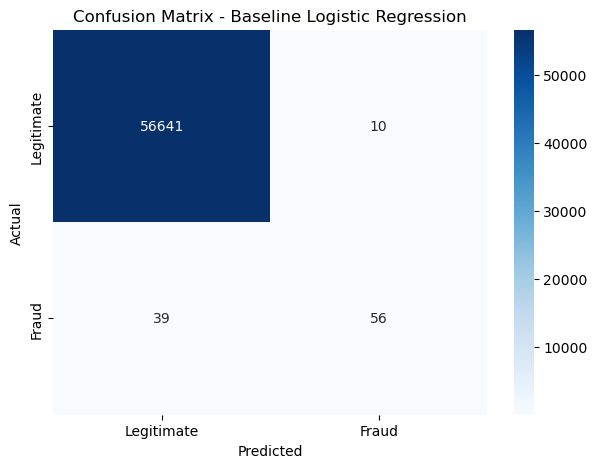

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9993    0.9998    0.9996     56651
       Fraud     0.8485    0.5895    0.6957        95

    accuracy                         0.9991     56746
   macro avg     0.9239    0.7946    0.8476     56746
weighted avg     0.9991    0.9991    0.9991     56746



In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Class-Weighted Logistic Regression
weighted_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Train
weighted_lr.fit(X_train, y_train)

# Predictions
y_pred_weighted = weighted_lr.predict(X_test)

# Classification Report
print("Class-Weighted Logistic Regression")
print(classification_report(
    y_test,
    y_pred_weighted,
    target_names=['Legitimate', 'Fraud']
))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Class-Weighted Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.09        95

    accuracy                           0.97     56746
   macro avg       0.52      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



Confusion Matrix:
[[55000  1651]
 [   12    83]]


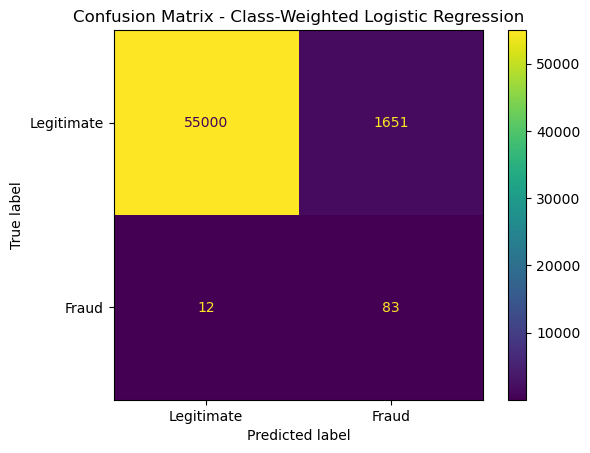

In [20]:
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

print("Confusion Matrix:")
print(cm_weighted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=['Legitimate', 'Fraud']
)

disp.plot()
plt.title("Confusion Matrix - Class-Weighted Logistic Regression")
plt.show()

### Class-Weighted Logistic Regression:
To address the severe class imbalance, Logistic Regression was trained using class_weight='balanced'. Compared with the baseline model, the class-weighted model substantially improved fraud detection, increasing fraud recall from 58.95% to 87% and reducing false negatives from 39 to 12. However, this improvement came at the cost of a significant increase in false positives, from 10 to 1,818, resulting in a very low fraud precision of 4%. This demonstrates the trade-off between detecting more fraudulent transactions and generating false fraud alerts.

# SMOTE + LR

In [23]:
from imblearn.over_sampling import SMOTE


from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)


Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



SMOTE + Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56651
       Fraud       0.12      0.84      0.21        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     56746
weighted avg       1.00      0.99      0.99     56746


Confusion Matrix:
[[56060   591]
 [   15    80]]


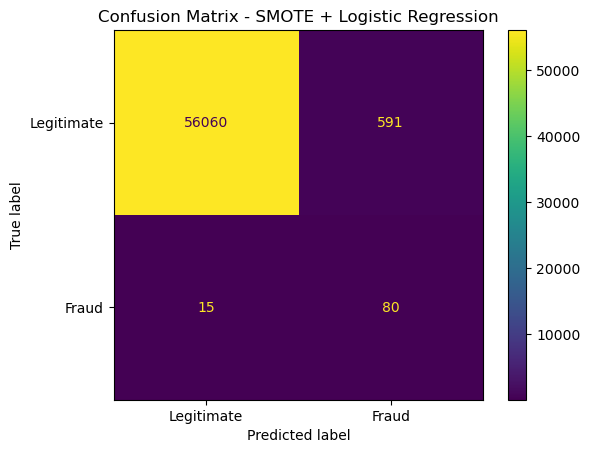


ROC-AUC: 0.9513778267490052
PR-AUC: 0.6956529380850907


In [69]:
# ============================================
# 1. APPLY SMOTE
# ============================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


# ============================================
# 2. TRAIN LOGISTIC REGRESSION
# ============================================

smote_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_lr.fit(
    X_train_smote,
    y_train_smote
)


# ============================================
# 3. PREDICTIONS
# ============================================

y_pred_smote = smote_lr.predict(X_test)


# ============================================
# 4. CLASSIFICATION REPORT
# ============================================

print("\nSMOTE + Logistic Regression")
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=['Legitimate', 'Fraud'],
        zero_division=0
    )
)


# ============================================
# 5. CONFUSION MATRIX
# ============================================

cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

print("\nConfusion Matrix:")
print(cm_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=['Legitimate', 'Fraud']
)

disp.plot()
plt.title("Confusion Matrix - SMOTE + Logistic Regression")
plt.show()


# ============================================
# 6. ROC-AUC AND PR-AUC
# ============================================

y_prob_smote = smote_lr.predict_proba(X_test)[:, 1]

roc_auc_smote = roc_auc_score(
    y_test,
    y_prob_smote
)

pr_auc_smote = average_precision_score(
    y_test,
    y_prob_smote
)

print("\nROC-AUC:", roc_auc_smote)
print("PR-AUC:", pr_auc_smote)

# Scaled SMOTE + LR

In [57]:
# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [59]:
# ============================================
# TRAIN LOGISTIC REGRESSION
# ============================================

smote_lr_scaled = LogisticRegression(
    max_iter=5000,
    random_state=42
)

smote_lr_scaled.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=5000, random_state=42)

In [61]:
# ============================================
# PREDICTION
# ============================================

y_pred_smote_scaled = smote_lr_scaled.predict(
    X_test_scaled
)


In [63]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nSMOTE + Scaled Logistic Regression")

print(
    classification_report(
        y_test,
        y_pred_smote_scaled,
        target_names=['Legitimate', 'Fraud'],
        zero_division=0
    )
)


SMOTE + Scaled Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



In [65]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm_smote_scaled = confusion_matrix(
    y_test,
    y_pred_smote_scaled
)

print("\nConfusion Matrix:")
print(cm_smote_scaled)


Confusion Matrix:
[[55119  1532]
 [   12    83]]


### 📈 Model Evaluation & Comparison

| Model | Precision | Recall | F1-Score | False Positives (FP) | False Negatives (FN) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Baseline LR** | **84.85%** | 58.95% | **69.57%** | **10** | 39 |
| **Class-Weighted LR** | 4.00% | **87.00%** | 8.00% | 1,818 | **12** |
| **SMOTE + LR** | 12.00% | 85.00% | 21.00% | 590 | 14 |
| **Scaled SMOTE + LR** | 5.00% | **87.00%** | 10.00% | 1,532 | **12** |

> **Key Trade-off Observation:**
> * **Baseline LR** achieves the highest **Precision (84.85%)** and **F1-Score (69.57%)** with very few False Positives ($10$), but misses more actual cases ($39$ FN).
> * **Resampling / Class Weighting** significantly boosts **Recall (up to 87%)** by reducing False Negatives ($12$), but results in a massive surge in False Positives ($1,500+$ FP) which dilutes Precision.

# Use the better SMOTE model for threshold tuning

In [75]:
# Get fraud probabilities from SMOTE model
y_prob_smote = smote_lr.predict_proba(X_test)[:, 1]


# Test different thresholds
thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_smote >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


threshold_results = pd.DataFrame(results)

print(threshold_results)

    Threshold  Precision    Recall        F1
0        0.05   0.008446  0.915789  0.016737
1        0.10   0.016841  0.915789  0.033074
2        0.15   0.026053  0.905263  0.050648
3        0.20   0.035993  0.873684  0.069138
4        0.25   0.047977  0.873684  0.090959
5        0.30   0.060383  0.863158  0.112870
6        0.35   0.073303  0.852632  0.135000
7        0.40   0.086631  0.852632  0.157282
8        0.45   0.101250  0.852632  0.181006
9        0.50   0.119225  0.842105  0.208877
10       0.55   0.136678  0.831579  0.234770
11       0.60   0.157685  0.831579  0.265101
12       0.65   0.178899  0.821053  0.293785
13       0.70   0.214286  0.821053  0.339869
14       0.75   0.253247  0.821053  0.387097
15       0.80   0.302326  0.821053  0.441926
16       0.85   0.369668  0.821053  0.509804
17       0.90   0.441176  0.789474  0.566038
18       0.95   0.619835  0.789474  0.694444


In [77]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print("Best Threshold Based on F1:")
print(best_threshold_row)

Best Threshold Based on F1:
Threshold    0.950000
Precision    0.619835
Recall       0.789474
F1           0.694444
Name: 18, dtype: float64


In [79]:
# Best threshold for precision
best_precision = threshold_results.loc[
    threshold_results["Precision"].idxmax()
]

# Best threshold for recall
best_recall = threshold_results.loc[
    threshold_results["Recall"].idxmax()
]

# Best threshold for F1
best_f1 = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print("Best Precision:")
print(best_precision)

print("\nBest Recall:")
print(best_recall)

print("\nBest F1:")
print(best_f1)

Best Precision:
Threshold    0.950000
Precision    0.619835
Recall       0.789474
F1           0.694444
Name: 18, dtype: float64

Best Recall:
Threshold    0.050000
Precision    0.008446
Recall       0.915789
F1           0.016737
Name: 0, dtype: float64

Best F1:
Threshold    0.950000
Precision    0.619835
Recall       0.789474
F1           0.694444
Name: 18, dtype: float64


### SMOTE catches more fraud but generates many false alarms.

So your project is demonstrating a very important phenomenon:

Handling class imbalance does not automatically improve every evaluation metric.

That's actually a good finding.

# ------------------

Technically this is correct.

But don't say that 0.05 is the best threshold overall.

It is only:

the threshold that maximizes recall among the tested thresholds.

At 0.05, you catch about 92% of fraud, but precision is only 0.84%.

That means almost everything you flag as fraud would actually be legitimate.

So for a practical fraud detection system, that's probably too many false alarms.

### And after SMOTE + threshold tuning:

Precision = 0.6198

Recall    = 0.7895

F1        = 0.6944

### original Logistic Regression already had:

Precision = 0.8485

Recall    = 0.5895

F1        = 0.6957